# Image Manipulation  - Transalation

#### affine translation
#### we use cv2.warpAffine to implement these transformation

#### Rotaions
##### cv2.getRotationMatrix2D(rotation_center_x, rotation_center_y, angle_of_rotation, scale)

In [12]:
import os
import numpy as np
import pandas as pd
import cv2

image = cv2.imread('input.jpg')

# stope height and width of the image
height, width = image.shape[:2]

quarter_height, quarter_width = height/4, width/4

# T = |1 0 Tx|
#    |0 1 Ty|
# T is our translation matrix

T = np.float32([[1,0, quarter_width],[0,1,quarter_height]])

# we use warpAffine to transform the image using the matrix, T

img_translation = cv2.warpAffine(image, T, (width, height))

cv2.imshow('Translation Image', img_translation)
cv2.imshow('Original Image', image)
cv2.waitKey()
cv2.destroyAllWindows()

In [2]:
image.shape

(415, 622, 3)

In [3]:
image.shape[:2]

(415, 622)

In [5]:
622/4

155.5

In [7]:
print(T)

[[  1.     0.   155.5 ]
 [  0.     1.   103.75]]


In [15]:
# Rotations
# cv2.getRotationMatrix2D()


image = cv2.imread('input.jpg')

# stope height and width of the image
height, width = image.shape[:2]

# Divide by two to rotate the image around its centre
rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2),90,.5)
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
cv2.imshow('Rotated Image', rotated_image)
cv2.imshow('Translation Image', img_translation)
cv2.imshow('Original Image', image)
cv2.waitKey()
cv2.destroyAllWindows()

In [9]:
rotated_image.shape

(415, 622, 3)

In [18]:
image = cv2.imread('input.jpg')
rotated_image = cv2.transpose(image)
cv2.imshow('Rotated image - method 2', rotated_image)
#cv2.imshow('Rotated Image', rotated_image)
#cv2.imshow('Translation Image', img_translation)
#cv2.imshow('Original Image', image)
cv2.waitKey()
cv2.destroyAllWindows()


In [19]:
flipped = cv2.flip(image, 1)
cv2.imshow('Rotated image - method 2', rotated_image)
cv2.imshow('Horizontal Flip', flipped)
cv2.waitKey()
cv2.destroyAllWindows()

# Re-sizing, scaling and interpolation

In [22]:
image = cv2.imread('input.jpg')

cv2.imshow('Original Image', image)
cv2.waitKey()
# let's make our image 3/4 of it's original size
image_scaled = cv2.resize(image, None, fx=0.75, fy=0.75)
cv2.imshow('scaling - Linear Interpolation', image_scaled)
cv2.waitKey()

image_scaled1 = cv2.resize(image, None, fx=2, fy=2, interpolation = cv2.INTER_CUBIC)
cv2.imshow('scaling - Cubic Interpolation', image_scaled1)
cv2.waitKey()

image_scaled2 = cv2.resize(image, (900,400),interpolation = cv2.INTER_NEAREST)
cv2.imshow('scaling - Skewd size', image_scaled2)
cv2.waitKey()

cv2.destroyAllWindows()

In [23]:
def show_pic(img):
    fig = plt.figure(figsize=(15,15))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

<IPython.core.display.Javascript object>

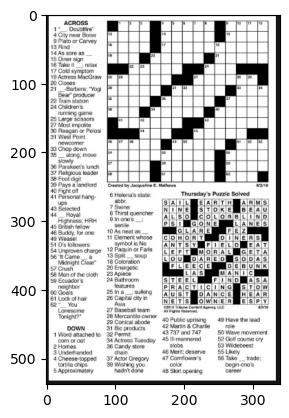

In [24]:
img = cv2.imread('crossword.PNG', 0)
plt.imshow(img, cmap='gray')

<IPython.core.display.Javascript object>

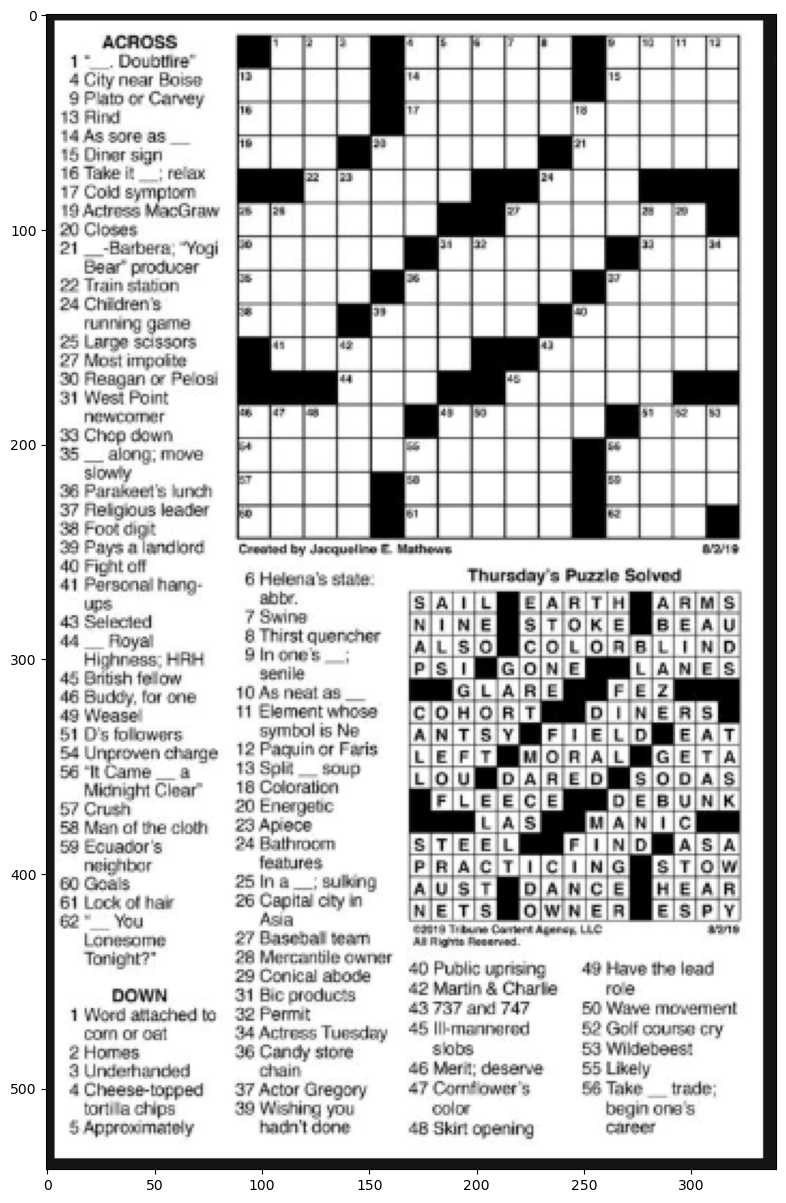

In [25]:
show_pic(img)

<IPython.core.display.Javascript object>

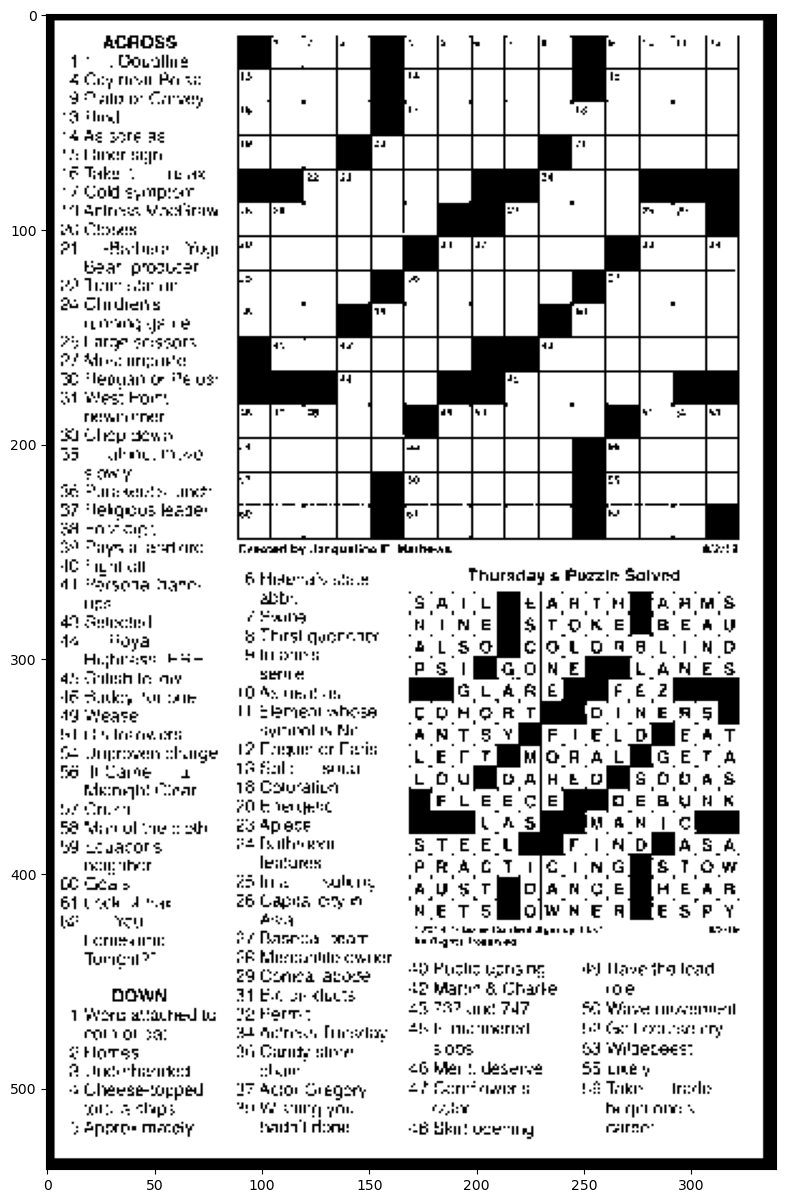

In [26]:
ret, img1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
show_pic(img1)

In [27]:
image = cv2.imread('input.jpg')

cv2.imshow('Original Image', image)
cv2.waitKey()
cv2.destroyAllWindows()

# Pyramids

In [30]:
image = cv2.imread('input.jpg')

smaller = cv2.pyrDown(image)

larger = cv2.pyrUp(image)

cv2.imshow('Original', image)
cv2.imshow('Smaller', smaller)
cv2.imshow('Larger', larger)
cv2.waitKey()
cv2.destroyAllWindows()

# Cropping

In [31]:
image = cv2.imread('input.jpg')
height, width = image.shape[:2]

start_row, start_col = int(height * 0.25), int(width * 0.25)
end_row, end_col = int(height * 0.75), int(width * 0.75)

cropped = image[start_row:end_row,start_col:end_col ]

cv2.imshow("Original Image", image)
cv2.waitKey()

cv2.imshow("Cropped Image", cropped)
cv2.waitKey()

cv2.destroyAllWindows()

# Live Project using webcam

In [32]:
import cv2
import numpy as np

# our sketch generation function
def sketch(image):
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Clean up image using Guassian Blur
    img_gray_blur = cv2.GaussianBlur(img_gray, (5,5), 0)
    # extract edges 
    canny_edges = cv2.Canny(img_gray_blur, 10, 70)
    
    ret, mask = cv2.threshold(canny_edges, 70, 255, cv2.THRESH_BINARY_INV)
    return mask

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    cv2.imshow("Our Live Sketch Video", sketch(frame) )
    if cv2.waitKey(1) ==13:
        break
        
cap.release()
cv2.destroyAllWindows()